In [1]:
import polars as pl

cresta_no_msa = pl.read_parquet(
    "../../data/cresta_no_msa/triad/cresta_triad.conf_af3.parquet"
)

In [2]:
from tcrtrifold.utils import FORMAT_ANTIGEN_COLS
import numpy as np
import polars as pl
from sklearn.metrics import auc
import sklearn.metrics as metrics
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from sklearn import metrics


def antigen_raw_score_summary(
    triad_dataset, featname, grouping_cols=FORMAT_ANTIGEN_COLS, mhc_class="I"
):

    antigens = triad_dataset.select(grouping_cols).unique()

    out_df = []

    for row in antigens.iter_rows(named=True):
        antigen = pl.DataFrame([row]).select(pl.exclude("job_name"))
        aucs = []
        focal_antigen_triads = triad_dataset.join(
            antigen, on=grouping_cols, nulls_equal=True
        )

        new_row = {}

        dat = focal_antigen_triads.select(featname, "cognate").to_numpy()

        fpr, tpr, threshold = metrics.roc_curve(dat[:, 1], dat[:, 0])
        roc_auc = metrics.auc(fpr, tpr)
        new_row["roc_auc"] = roc_auc
        new_row["fpr"] = fpr.tolist()
        new_row["tpr"] = tpr.tolist()
        if mhc_class == "I":
            new_row["name"] = row["mhc_1_name"] + "::" + row["peptide"]
        else:
            new_row["name"] = row["mhc_2_name"] + "::" + row["peptide"]
        out_df.append(new_row)

    summary_row = {}
    dat = triad_dataset.select(featname, "cognate").to_numpy()
    fpr, tpr, threshold = metrics.roc_curve(dat[:, 1], dat[:, 0])
    roc_auc = metrics.auc(fpr, tpr)
    summary_row["roc_auc"] = roc_auc
    summary_row["fpr"] = fpr.tolist()
    summary_row["tpr"] = tpr.tolist()
    summary_row["name"] = "All antigen"

    out_df.append(summary_row)

    return pl.DataFrame(out_df)


def antigen_auc_summary_and_plot(
    triad_dataset: pl.DataFrame,
    featname: str,
    grouping_cols,
    mhc_class: str = "I",
    ax: plt.Axes | None = None,
    title: str | None = None,
    jitter: float = 0.01,  # line jitter so curves don't perfectly overlap
    jitter_seed: int | None = 0,
):
    """
    Computes per-antigen ROC (AUC, AUC@0.1, FPR, TPR) + an 'All antigen' summary,
    and plots ROC curves with small jitter. Legend still shows overall AUC only.
    """
    antigens = triad_dataset.select(grouping_cols).unique()
    rows = []

    for row in antigens.iter_rows(named=True):
        antigen_df = pl.DataFrame([row]).select(pl.exclude("job_name"))
        focal = triad_dataset.join(antigen_df, on=grouping_cols, nulls_equal=True)

        dat = focal.select(featname, "cognate").to_numpy()
        y_score = dat[:, 0]
        y_true = dat[:, 1]

        fpr, tpr, _ = metrics.roc_curve(y_true, y_score)
        auc = metrics.auc(fpr, tpr)
        auc_01 = metrics.roc_auc_score(y_true, y_score, max_fpr=0.1)

        name = (
            f"{row['mhc_1_name']}::{row['peptide']}"
            if mhc_class == "I"
            else f"{row['mhc_2_name']}::{row['peptide']}"
        )
        rows.append(
            {
                "name": name,
                "roc_auc": float(auc),
                "roc_auc_0_1": float(auc_01),  # standardized pAUC@0.1
                "fpr": fpr.tolist(),
                "tpr": tpr.tolist(),
            }
        )

    # Add overall 'All antigen'
    dat_all = triad_dataset.select(featname, "cognate").to_numpy()
    y_score_all = dat_all[:, 0]
    y_true_all = dat_all[:, 1]
    fpr_all, tpr_all, _ = metrics.roc_curve(y_true_all, y_score_all)
    auc_all = metrics.auc(fpr_all, tpr_all)
    auc_01_all = metrics.roc_auc_score(y_true_all, y_score_all, max_fpr=0.1)

    rows.append(
        {
            "name": "All antigen",
            "roc_auc": float(auc_all),
            "roc_auc_0_1": float(auc_01_all),
            "fpr": fpr_all.tolist(),
            "tpr": tpr_all.tolist(),
        }
    )

    summary_df = pl.DataFrame(rows)

    # ---------- plotting ----------
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    rng = np.random.default_rng(jitter_seed)

    def _jitter_curve(fpr, tpr):
        dx = rng.uniform(-jitter, jitter)
        dy = rng.uniform(-jitter, jitter)
        fpr_j = np.clip(np.asarray(fpr, float) + dx, 0.0, 1.0)
        tpr_j = np.clip(np.asarray(tpr, float) + dy, 0.0, 1.0)
        return fpr_j, tpr_j

    # Plot All antigen first (so it appears first in legend)
    all_row = summary_df.filter(pl.col("name") == "All antigen").row(0, named=True)
    fpr_j, tpr_j = _jitter_curve(all_row["fpr"], all_row["tpr"])
    ax.plot(
        fpr_j,
        tpr_j,
        lw=2.5,
        color="black",
        label=f"{all_row['name']} (AUC {all_row['roc_auc']:.2f}) (AUC@0.1 {all_row['roc_auc_0_1']:.2f})",
        zorder=3,
    )

    # Plot other antigens
    for row in summary_df.filter(pl.col("name") != "All antigen").iter_rows(named=True):
        fpr_j, tpr_j = _jitter_curve(row["fpr"], row["tpr"])
        ax.plot(
            fpr_j,
            tpr_j,
            lw=1.2,
            label=f"{row['name']} (AUC {row['roc_auc']:.2f}) (AUC@0.1 {row['roc_auc_0_1']:.2f})",
            # If you want to also show AUC@0.1, add:
            # f" (AUC@0.1 {row['roc_auc_0_1']:.2f})"
        )

    ax.plot([0, 1], [0, 1], "--", lw=1, color="grey")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    if title:
        ax.set_title(title)
    ax.legend(loc="lower right", fontsize=6)
    ax.grid(True)

    return summary_df, ax

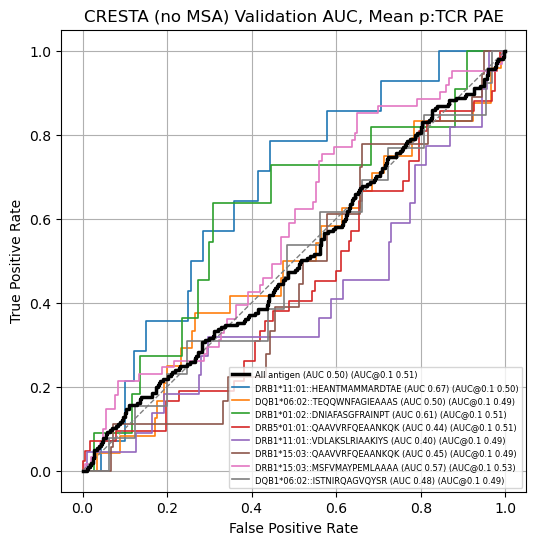

In [3]:
from tcrtrifold.eval_utils import antigen_raw_score_auc
from tcrtrifold.viz_utils import plot_auc_per_antigen
from sklearn import metrics

auc_df = antigen_auc_summary_and_plot(
    cresta_no_msa.with_columns((1 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae")),
    "mean_p_tcr_pae",
    grouping_cols=["peptide", "mhc_2_name"],
    mhc_class="II",
    jitter=0,
    title="CRESTA (no MSA) Validation AUC, Mean p:TCR PAE",
)

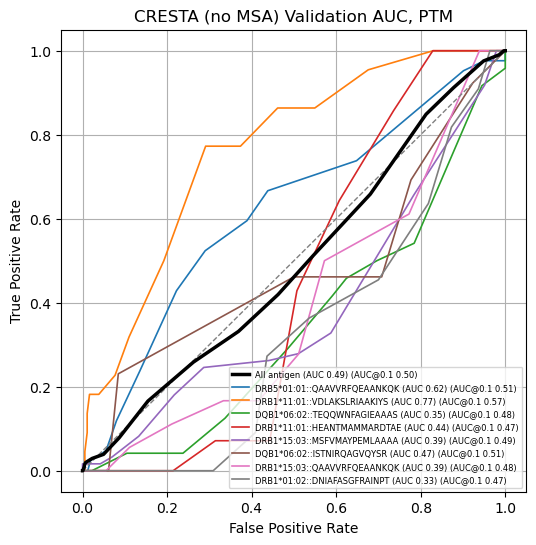

In [5]:
from tcrtrifold.eval_utils import antigen_raw_score_auc
from tcrtrifold.viz_utils import plot_auc_per_antigen
from sklearn import metrics

auc_df = antigen_auc_summary_and_plot(
    cresta_no_msa,
    "ptm",
    grouping_cols=["peptide", "mhc_2_name"],
    mhc_class="II",
    jitter=0,
    title="CRESTA (no MSA) Validation AUC, PTM",
)